In [0]:
import pandas as pd
import numpy as np


In [0]:
%pip install openpyxl

Looking in indexes: [REDACTED]
Note: you may need to restart the kernel using %restart_python or dbutils.library.restartPython() to use updated packages.


In [0]:

df = pd.read_excel("/Volumes/retail/default/retail/1785258801617_Sales_Case_Study_2021_1.xlsx")

In [0]:
df.head()

,Date,Sales,Cost Of Sales,Quantity Sold
0,2013-12-30,223937.967870,230079.621012,6827
1,2013-12-31,300345.484564,306986.120484,9268
2,2014-01-01,86782.467727,87986.318214,2678
3,2014-01-02,200173.116753,202881.177706,6175
4,2014-01-03,326906.074176,333806.291873,10084


Exploratory Data Analysis 

In [0]:
df

,Date,Sales,Cost Of Sales,Quantity Sold
0,2013-12-30,223937.967870,230079.621012,6827
1,2013-12-31,300345.484564,306986.120484,9268
2,2014-01-01,86782.467727,87986.318214,2678
3,2014-01-02,200173.116753,202881.177706,6175
4,2014-01-03,326906.074176,333806.291873,10084
...,...,...,...,...
1048,2016-11-12,164998.844641,156263.149474,3843
1049,2016-11-13,97946.783047,93112.608909,2281
1050,2016-11-14,87834.253684,83068.269027,2046
1051,2016-11-15,95509.134975,88104.204530,2181


In [0]:
df.columns

Index(['Date', 'Sales', 'Cost Of Sales', 'Quantity Sold'], dtype='object')

In [0]:
df.describe()

,Date,Sales,Cost Of Sales,Quantity Sold
count,1053,1053.000000,1053.000000,1053.000000
mean,2015-06-09 00:00:00,177502.211070,184260.312865,5014.123457
min,2013-12-30 00:00:00,20495.113025,18375.052608,508.000000
25%,2014-09-19 00:00:00,80697.903501,78096.760182,2046.000000
50%,2015-06-09 00:00:00,141913.382430,143791.478082,3843.000000
75%,2016-02-27 00:00:00,236305.156366,250572.453388,6781.000000
max,2016-11-16 00:00:00,846678.388161,872081.585004,26410.000000
std,NaN,127548.391962,138912.894312,3901.251594


In [0]:
df.isnull().sum()

Date             0
Sales            0
Cost Of Sales    0
Quantity Sold    0
dtype: int64

In [0]:
df.duplicated().sum()

np.int64(0)

Data Cleaning

In [0]:
# Convert Date column to datetime format
df["Date"] = pd.to_datetime(df["Date"])

# Check the data type
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1053 entries, 0 to 1052
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Date           1053 non-null   datetime64[ns]
 1   Sales          1053 non-null   float64       
 2   Cost Of Sales  1053 non-null   float64       
 3   Quantity Sold  1053 non-null   int64         
dtypes: datetime64[ns](1), float64(2), int64(1)
memory usage: 33.0 KB


In [0]:
df.head()

,Date,Sales,Cost Of Sales,Quantity Sold
0,2013-12-30,223937.967870,230079.621012,6827
1,2013-12-31,300345.484564,306986.120484,9268
2,2014-01-01,86782.467727,87986.318214,2678
3,2014-01-02,200173.116753,202881.177706,6175
4,2014-01-03,326906.074176,333806.291873,10084


 metrics

In [0]:
# Create Daily Sales Price per Unit
df["Sales Price Per Unit"] = df["Sales"] / df["Quantity Sold"]

# View the results
df.head(3)

,Date,Sales,Cost Of Sales,Quantity Sold,Sales Price Per Unit
0,2013-12-30,223937.967870,230079.621012,6827,32.801812
1,2013-12-31,300345.484564,306986.120484,9268,32.406720
2,2014-01-01,86782.467727,87986.318214,2678,32.405701


In [0]:
# Average Unit Sales Price
average_unit_price = df["Sales Price Per Unit"].mean()

print(f"Average Unit Sales Price: R{average_unit_price:.2f}")


Average Unit Sales Price: R37.07


In [0]:
df.head(3)

,Date,Sales,Cost Of Sales,Quantity Sold,Sales Price Per Unit
0,2013-12-30,223937.967870,230079.621012,6827,32.801812
1,2013-12-31,300345.484564,306986.120484,9268,32.406720
2,2014-01-01,86782.467727,87986.318214,2678,32.405701


This means:

On average, the product was sold for R58.74 per unit during the period covered by the dataset.

This is an important KPI because it tells management the typical selling price of the product over time.

In [0]:
# Create Daily Gross Profit
df["Gross Profit"] = df["Sales"] - df["Cost Of Sales"]

# Display the first few rows
df[["Date", "Sales", "Cost Of Sales", "Gross Profit"]].head(3)

,Date,Sales,Cost Of Sales,Gross Profit
0,2013-12-30,223937.967870,230079.621012,-6141.653143
1,2013-12-31,300345.484564,306986.120484,-6640.635920
2,2014-01-01,86782.467727,87986.318214,-1203.850487


In [0]:
# Daily Gross Profit Percentage
# Create Gross Profit Percentage
df["Gross Profit %"] = (df["Gross Profit"] / df["Sales"]) * 100
# Round to 2 decimal places
df["Gross Profit %"] = df["Gross Profit %"].round(2)

# Display results
df[["Date", "Gross Profit", "Sales", "Gross Profit %"]].head(3)

,Date,Gross Profit,Sales,Gross Profit %
0,2013-12-30,-6141.653143,223937.967870,-2.74
1,2013-12-31,-6640.635920,300345.484564,-2.21
2,2014-01-01,-1203.850487,86782.467727,-1.39


In [0]:
# Daily Gross Profit per Unit

# Create Gross Profit per Unit
df["Gross Profit Per Unit"] = df["Gross Profit"] / df["Quantity Sold"]

# Round to 2 decimal places
df["Gross Profit Per Unit"] = df["Gross Profit Per Unit"].round(2)

# Display results
df[["Date", "Gross Profit", "Quantity Sold", "Gross Profit Per Unit"]].head()

,Date,Gross Profit,Quantity Sold,Gross Profit Per Unit
0,2013-12-30,-6141.653143,6827,-0.90
1,2013-12-31,-6640.635920,9268,-0.72
2,2014-01-01,-1203.850487,2678,-0.45
3,2014-01-02,-2708.060954,6175,-0.44
4,2014-01-03,-6900.217697,10084,-0.68


In [0]:
# Create Gross Profit Percentage per Unit
df["Gross Profit % Per Unit"] = (
    df["Gross Profit Per Unit"] /
    df["Sales Price Per Unit"]
) * 100

# Round to 2 decimal places
df["Gross Profit % Per Unit"] = df["Gross Profit % Per Unit"].round(2)

# Display the new metrics
df[
    [
        "Date",
        "Sales Price Per Unit",
        "Gross Profit Per Unit",
        "Gross Profit % Per Unit"
    ]
].head()

,Date,Sales Price Per Unit,Gross Profit Per Unit,Gross Profit % Per Unit
0,2013-12-30,32.801812,-0.90,-2.74
1,2013-12-31,32.406720,-0.72,-2.22
2,2014-01-01,32.405701,-0.45,-1.39
3,2014-01-02,32.416699,-0.44,-1.36
4,2014-01-03,32.418294,-0.68,-2.10


In [0]:
df.columns

Index(['Date', 'Sales', 'Cost Of Sales', 'Quantity Sold',
       'Sales Price Per Unit', 'Gross Profit', 'Gross Profit %',
       'Gross Profit Per Unit', 'Gross Profit % Per Unit'],
      dtype='object')

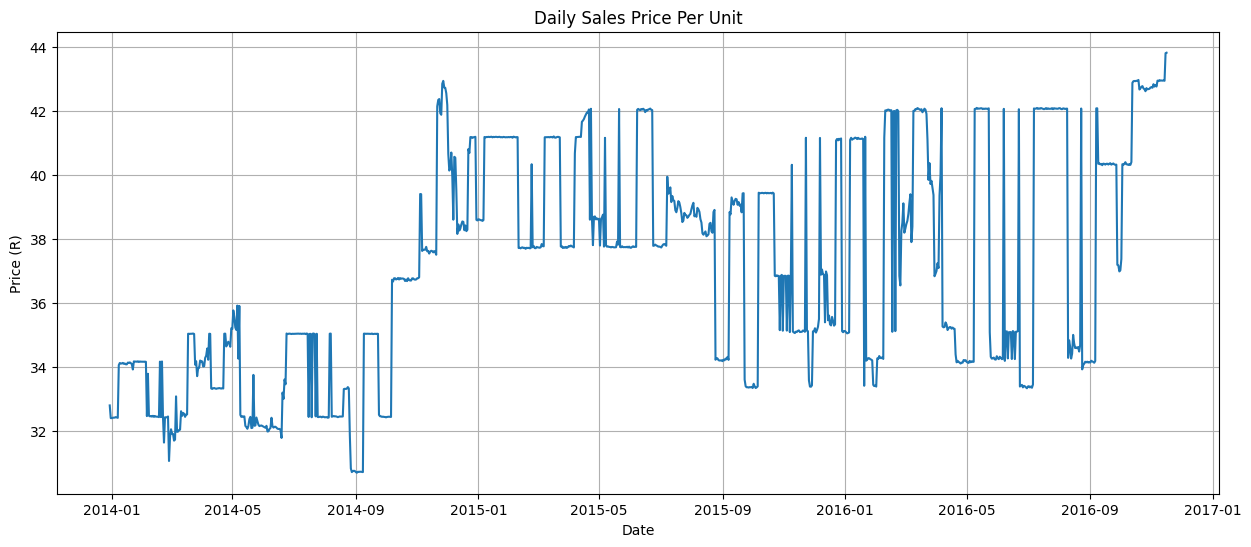

In [0]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15,6))

plt.plot(df["Date"], df["Sales Price Per Unit"])

plt.title("Daily Sales Price Per Unit")
plt.xlabel("Date")
plt.ylabel("Price (R)")
plt.grid(True)

plt.show()